# Assignment 4

Before working on this assignment please read these instructions fully. In the submission area, you will notice that you can click the link to **Preview the Grading** for each step of the assignment. This is the criteria that will be used for peer grading. Please familiarize yourself with the criteria before beginning the assignment.

This assignment requires that you find **at least two datasets** on the web which are related, and that you visualize these datasets to answer the assignment question. You are free to utilize datasets with any location or domain, the usage of **Ann Arbor sports and athletics** datasets in the example is just a suggestion.

You are welcome to choose datasets at your discretion, but keep in mind **they will be shared with your peers**, so choose appropriate datasets. Sensitive, confidential, illicit, and proprietary materials are not good choices for datasets for this assignment. You are welcome to upload datasets of your own as well, and link to them using a third party repository such as github, pastebin, etc. Please be aware of the Coursera terms of service with respect to intellectual property.

Also, you are welcome to preserve data in its original language, but for the purposes of grading you should provide english translations. You are welcome to provide multiple visuals in different languages if you would like!

As this assignment is for the whole course, you must incorporate principles discussed in the first week, such as having as high data-ink ratio (Tufte) and aligning with Cairo’s principles of truth, beauty, function, and insight.

Here are the assignment instructions:

 * You must state a question you are seeking to answer with your visualizations.
 * You must provide at least two links to available datasets. These could be links to files such as CSV or Excel files, or links to websites which might have data in tabular form, such as Wikipedia pages.
 * You must upload an image which addresses the research question you stated. In addition to addressing the question, this visual should follow Cairo's principles of truthfulness, functionality, beauty, and insightfulness.
 * You must contribute a short (1-2 paragraph) written justification of how your visualization addresses your stated research question.

## Tips
* Wikipedia is an excellent source of data, and I strongly encourage you to explore it for new data sources.
* Many governments run open data initiatives at the city, region, and country levels, and these are wonderful resources for localized data sources.
* Several international agencies, such as the [United Nations](http://data.un.org/), the [World Bank](http://data.worldbank.org/), the [Global Open Data Index](http://index.okfn.org/place/) are other great places to look for data.
* This assignment requires you to convert and clean datafiles. Check out the discussion forums for tips on how to do this from various sources, and share your successes with your fellow students!

## Example
Looking for an example? Here's what our course assistant put together as an example! [Example Solution File](./readonly/Assignment4_example.pdf)

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

df_growth = pd.read_csv("assets/Population Growth, Fertility and Mortality Indicators.csv")
df_growth = df_growth.drop("T03",axis=1)
columns = df_growth.iloc[0].tolist()
columns[0] = 'Region/Country/Area'
df_growth.columns = columns
df_growth = df_growth.drop(0).drop(["Footnotes","Source"],axis=1)
df_growth.head()

,Region/Country/Area,Year,Series,Value
1,"Total, all countries or areas",2010,Population annual rate of increase (percent),1.3
2,"Total, all countries or areas",2010,Total fertility rate (children per women),2.6
3,"Total, all countries or areas",2010,"Infant mortality for both sexes (per 1,000 liv...",37.1
4,"Total, all countries or areas",2010,"Maternal mortality ratio (deaths per 100,000 p...",254
5,"Total, all countries or areas",2010,Life expectancy at birth for both sexes (years),70.1


In [103]:
df_populat = pd.read_csv("assets/Population, Surface Area and Density.csv")
df_populat = df_populat.drop("T02",axis=1)
columns = df_populat.iloc[0].tolist()
columns[0] = 'Region/Country/Area'
df_populat.columns = columns
df_populat = df_populat.drop(0).drop(["Footnotes","Source"],axis=1)
df_populat.head()

,Region/Country/Area,Year,Series,Value
1,"Total, all countries or areas",2010,Population mid-year estimates (millions),"6,985.60"
2,"Total, all countries or areas",2010,Population mid-year estimates for males (milli...,"3,514.41"
3,"Total, all countries or areas",2010,Population mid-year estimates for females (mil...,"3,471.20"
4,"Total, all countries or areas",2010,Sex ratio (males per 100 females),101.2
5,"Total, all countries or areas",2010,Population aged 0 to 14 years old (percentage),27.1


In [104]:
continents = ["Africa","Asia","Northern America","South America","Australia","Europe"]
populat1 = df_populat[df_populat["Region/Country/Area"].isin(continents)]
growth1 = df_growth[df_growth["Region/Country/Area"].isin(continents)]
populat1["Series"].unique(),growth1["Series"].unique()

(array(['Population mid-year estimates (millions)',
        'Population mid-year estimates for males (millions)',
        'Population mid-year estimates for females (millions)',
        'Sex ratio (males per 100 females)',
        'Population aged 0 to 14 years old (percentage)',
        'Population aged 60+ years old (percentage)', 'Population density',
        'Surface area (thousand km2)'], dtype=object),
 array(['Population annual rate of increase (percent)',
        'Total fertility rate (children per women)',
        'Infant mortality for both sexes (per 1,000 live births)',
        'Maternal mortality ratio (deaths per 100,000 population)',
        'Life expectancy at birth for both sexes (years)',
        'Life expectancy at birth for males (years)',
        'Life expectancy at birth for females (years)'], dtype=object))

In [105]:
populat2 = populat1[populat1["Series"] == "Population density"]
populat2 = populat2.drop("Series",axis=1).groupby(["Region/Country/Area","Year"]).max().reset_index()
populat2["Value"].replace(',','', regex=True, inplace=True)
populat2["Value"] = populat2["Value"].astype(float)
list_df_populat = []
for i in range(6):
    list_df_populat.append(populat2[4*i:4*(i+1)])
    list_df_populat[0]["Value"].tolist()
populat2

,Region/Country/Area,Year,Value
0,Africa,2010,35.7
1,Africa,2015,40.6
2,Africa,2021,47.2
3,Africa,2022,48.3
4,Asia,2010,134.6
5,Asia,2015,142.2
6,Asia,2021,149.7
7,Asia,2022,150.6
8,Australia,2010,2.9
9,Australia,2015,3.1


In [106]:
area = populat1[populat1["Series"] == 'Surface area (thousand km2)'].drop(["Year","Series"],axis=1)
area = area.groupby("Region/Country/Area").max()
area["Value"].replace(',','', regex=True, inplace=True)
#area["Value"] = area["Value"].astype(float)
area = area["Value"].tolist()
area[0]

'29648'

In [107]:
growth2 = growth1[growth1["Series"]=='Population annual rate of increase (percent)'].drop("Series",axis=1)
growth2=growth2.groupby(["Region/Country/Area","Year"]).max().reset_index()
growth2["Value"] = growth2["Value"].astype(float)
list_df_growth = []
for i in range(6):
    list_df_growth.append(growth2[4*i:4*(i+1)])
    list_df_growth[0]["Value"].tolist()
list_df_growth[0]

,Region/Country/Area,Year,Value
0,Africa,2010,2.6
1,Africa,2015,2.6
2,Africa,2020,2.4
3,Africa,2022,2.3


<Figure size 640x480 with 0 Axes>

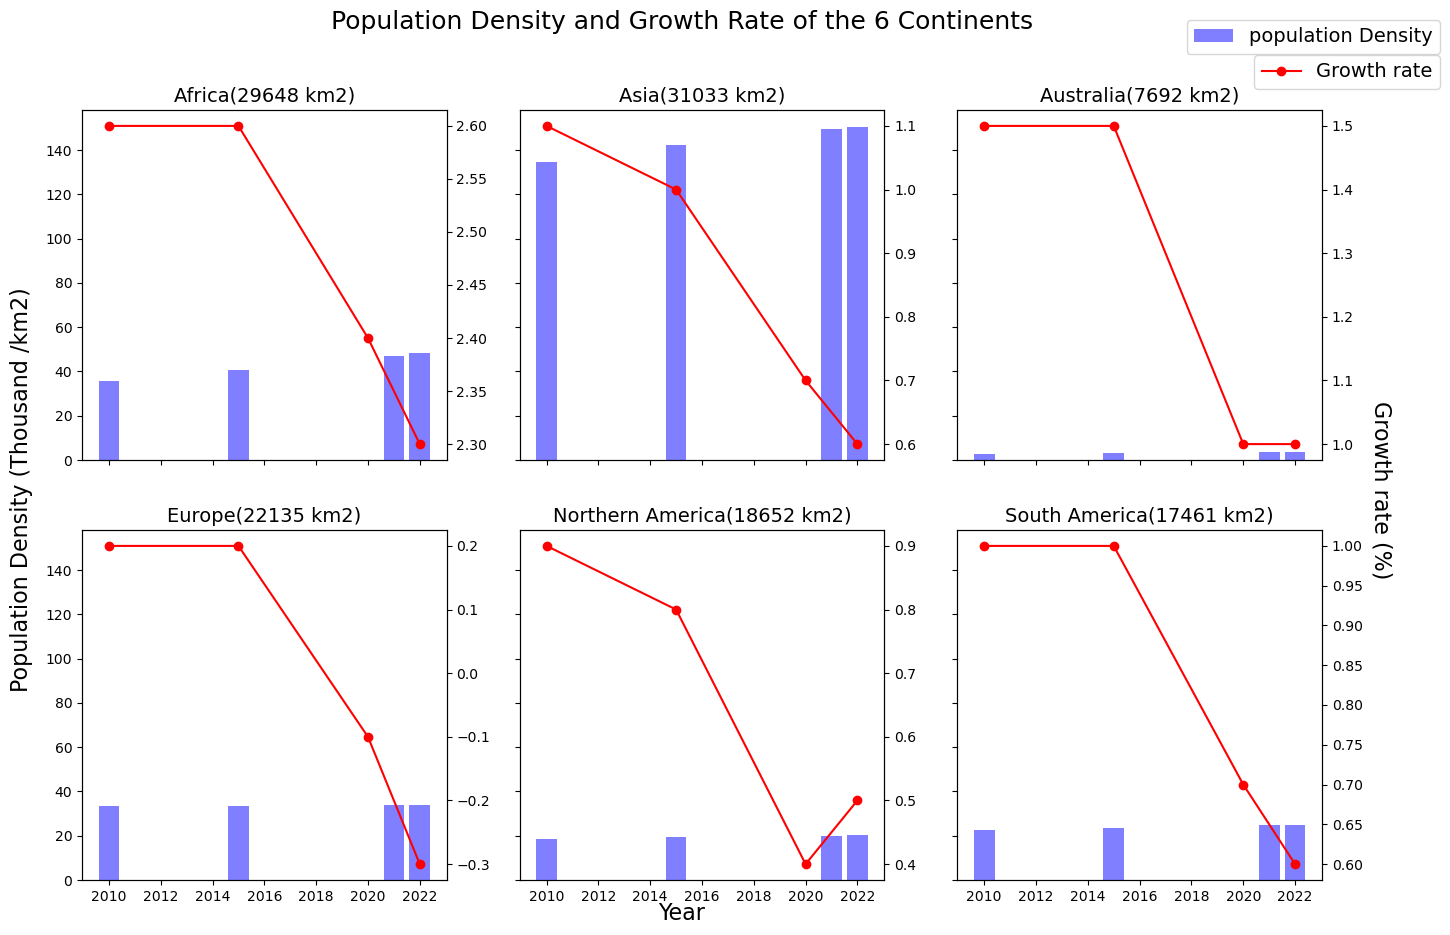

In [110]:

plt.figure()
fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, sharex=True,sharey=True,figsize=(16,10))
fig.suptitle("Population Density and Growth Rate of the 6 Continents",fontsize=18)
axs = [ax1,ax2,ax3,ax4,ax5,ax6]
#twinaxis = [ax7,ax8,ax9,ax10,ax11,ax12]
title = populat2["Region/Country/Area"].unique().tolist()
populat_year = [2010,2015,2021,2022]
rate_year = [2010,2015,2020,2022]
fig.text(0.5, 0.07, 'Year', ha='center',fontsize=16)
fig.text(0.08, 0.5, 'Population Density (Thousand /km2)', va='center', rotation='vertical',fontsize=16)
fig.text(0.93, 0.5, 'Growth rate (%)', va='center', rotation=270,fontsize=16);

for i in range(0,len(axs)):
    axs[i].bar(populat_year,list_df_populat[i]["Value"].tolist(),color="Blue",alpha=0.5, label="population Density")
    axy = axs[i].twinx()
    axy.plot(rate_year,list_df_growth[i]["Value"].tolist(),"-o",c="red", label="Growth rate")
    axs[i].set_title(title[i] + "({} km2)".format(area[i]),fontsize=14)
handles1, labels1 = axs[0].get_legend_handles_labels()
handles2, labels2 = axy.get_legend_handles_labels()
fig.legend(handles1, labels1, loc='upper right', bbox_to_anchor=(0.98, 0.98), ncol=2,fontsize=14)
fig.legend(handles2, labels2, loc='upper right', bbox_to_anchor=(0.98, 0.945), ncol=2,fontsize=14);
plt.savefig("Asm4.jpg")